In [1]:
!pip install -q tensorflow

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np

In [3]:
vocab_size = 10000   # Top 10,000 words only

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

# ============================================================
# 3. Padding Sequences
# Make all reviews same length
# ============================================================

max_len = 200

X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

print("Shape of Train Data:", X_train.shape)
print("Shape of Test Data :", X_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Samples: 25000
Testing Samples : 25000
Shape of Train Data: (25000, 200)
Shape of Test Data : (25000, 200)


In [4]:
model = Sequential()

# Word Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))

# LSTM Layer
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

# Dense Layer
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:

early_stop = EarlyStopping(monitor='val_loss', patience=2)

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 230s 718ms/step - accuracy: 0.7505 - loss: 0.5024 - val_accuracy: 0.8186 - val_loss: 0.3974
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 218s 697ms/step - accuracy: 0.8516 - loss: 0.3634 - val_accuracy: 0.8048 - val_loss: 0.4187
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 220s 704ms/step - accuracy: 0.8867 - loss: 0.2885 - val_accuracy: 0.8276 - val_loss: 0.4102


782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.8184 - loss: 0.4207

Test Accuracy: 81.83599710464478 %


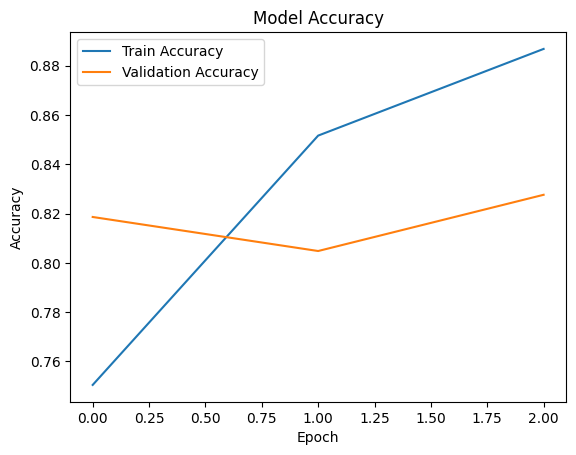

In [7]:

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy*100, "%")

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

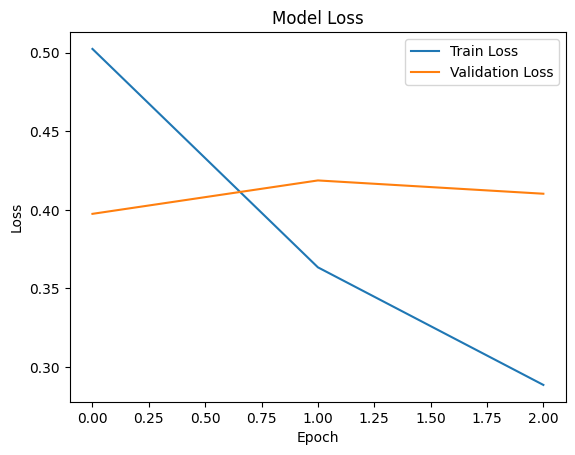

In [8]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [9]:
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []
    for word in words:
        if word in word_index and word_index[word] < vocab_size:
            encoded.append(word_index[word] + 3)
        else:
            encoded.append(2)
    return pad_sequences([encoded], maxlen=max_len)


review = "This movie was amazing and wonderful"

encoded_review = encode_review(review)

prediction = model.predict(encoded_review)

print("\nPrediction Score:", prediction[0][0])

if prediction[0][0] > 0.5:
    print("Sentiment: Positive ")
else:
    print("Sentiment: Negative ")

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step

Prediction Score: 0.9505339
Sentiment: Positive 
